In [1]:
import jones_tensor
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

This example shows how to use GPU acceleration for large knots and links. We work with PyTorch here, but CuPy/Jax/MLX also work and should be essentially the same. See the [autoray docs](https://autoray.readthedocs.io) for more information.

Now let's create a torus knot with 99 crossings from a braid:

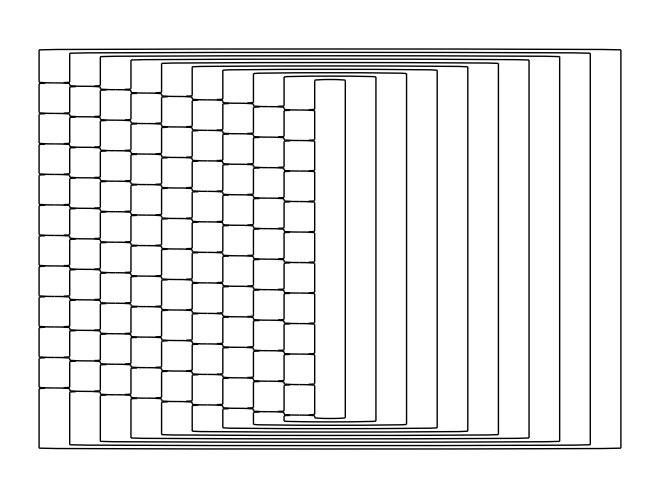

In [2]:
torus_10_11 = jones_tensor.MorseLink.from_braid([1, 2, 3, 4, 5, 6, 7, 8, 9] * 11)
torus_10_11.draw(unoriented=True)

And evaluate it for 1000 points around the unit circle. First using the CPU:

Calculation with the CPU took: 15.4242 seconds


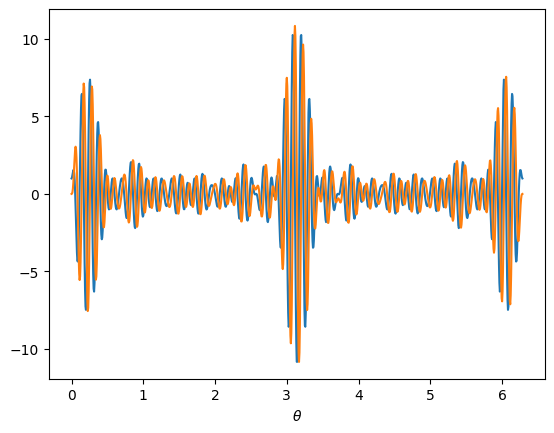

In [5]:
qs = np.exp(1j * np.linspace(0, 2*np.pi, 1000))

before = time.time()
jones = jones_tensor.evaluate_jones(qs, torus_10_11, optimize='auto', backend='torch')
after = time.time()

plt.plot(np.linspace(0, 2*np.pi, 1000), jones.real)
plt.plot(np.linspace(0, 2*np.pi, 1000), jones.imag)
plt.xlabel("$\\theta$")

print(f"Calculation with the CPU took: {after - before:g} seconds")

Now we can do that again but setting the PyTorch device as the GPU: 

Calculation with the GPU took: 3.53108 seconds


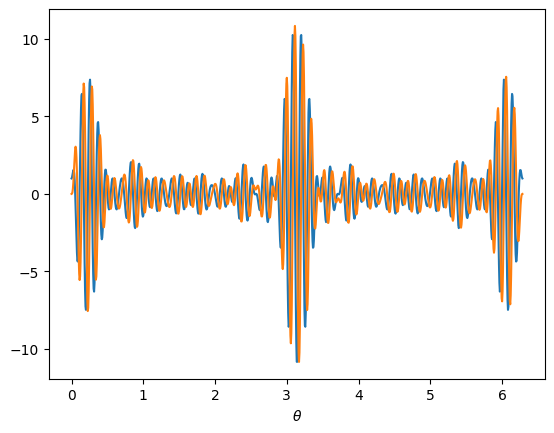

In [4]:
qs = np.exp(1j * np.linspace(0, 2*np.pi, 1000))

before = time.time()
with torch.device('cuda'):
    jones = jones_tensor.evaluate_jones(qs, torus_10_11, optimize='auto', backend='torch')
after = time.time()

plt.plot(np.linspace(0, 2*np.pi, 1000), jones.real)
plt.plot(np.linspace(0, 2*np.pi, 1000), jones.imag)
plt.xlabel("$\\theta$")

print(f"Calculation with the GPU took: {after - before:g} seconds")

In both cases we get the same result, but the GPU was substantially faster! 

(NB: you may need to run this several times to get accurate comparisons, because the contraction pathfinding is cached between runs and contributes a non-trivial amount of time)